In [ ]:
############## EDA ##############

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
years = ['2015', '2016', '2017', '2018', '2019']
dfs = {}

for year in years :
  dfs[year] = pd.read_csv(f"/content/drive/MyDrive/ETL/workshop003/DATA/{year}.csv")
  dfs[year]['Year'] = int(year)
for year in years:
  print(f"=== {year} Columns ===")
  print(dfs[year].columns.tolist())
  print("\n")



=== 2015 Columns ===
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']


=== 2016 Columns ===
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'Year']


=== 2017 Columns ===
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Year']


=== 2018 Columns ===
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corru

In [4]:
mapping = {
    # Target and Identifiers
    'Country or region': 'Country',
    'Happiness.Rank': 'Happiness Rank',
    'Overall rank': 'Happiness Rank',
    'Happiness.Score': 'Happiness Score',
    'Score': 'Happiness Score',

    # Features
    'Economy (GDP per Capita)': 'GDP per capita',
    'Economy..GDP.per.Capita.': 'GDP per capita',
    'Family': 'Social support',
    'Health (Life Expectancy)': 'Life Expectancy',
    'Health..Life.Expectancy.': 'Life Expectancy',
    'Healthy life expectancy': 'Life Expectancy',
    'Freedom to make life choices': 'Freedom',
    'Trust (Government Corruption)': 'Corruption',
    'Trust..Government.Corruption.': 'Corruption',
    'Perceptions of corruption': 'Corruption'
}


def standardize_columns(df: pd.DataFrame, mapping: dict) -> pd.DataFrame:
  """Standarsize columns based on a mapping dictionary"""
  return df.rename(columns=mapping)


dfs = {year: df.pipe(standardize_columns, mapping) for year, df in dfs.items()}

print("=== columns standarized ===")

=== columns standarized ===


In [5]:
df_all = pd.concat(dfs.values(), ignore_index=True)

#droped regions, standard errors, confidence intervals, and dystopia residuals

keep_columns = ['Country', 'Year', 'Happiness Rank',
                'Happiness Score', 'GDP per capita',
                'Social support', 'Life Expectancy',
                'Freedom', 'Generosity', 'Corruption']

df_clean = df_all[[col for col in keep_columns if col in df_all.columns]].copy()

#missing values

print("missing values")
print(df_clean.isnull().sum())


#using median to fill numeric values

num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())


print("\nMissing values after cleaning: ")
print(df_clean.isnull().sum())



missing values
Country            0
Year               0
Happiness Rank     0
Happiness Score    0
GDP per capita     0
Social support     0
Life Expectancy    0
Freedom            0
Generosity         0
Corruption         1
dtype: int64

Missing values after cleaning: 
Country            0
Year               0
Happiness Rank     0
Happiness Score    0
GDP per capita     0
Social support     0
Life Expectancy    0
Freedom            0
Generosity         0
Corruption         0
dtype: int64


In [6]:
#outlier_detection

def detect_outliers(df: pd.DataFrame, columns: list) -> pd.DataFrame:
  """Detect outliers in the specified columns using the IQR method"""
  df_clean_outliers = df.copy()
  initial_rows = len(df_clean_outliers)

  for col in columns:
    #Q1 (25%) and Q3(75%)
    Q1 = df_clean_outliers[col].quantile(0.25)
    Q3 = df_clean_outliers[col].quantile(0.75)

    # IQR
    IQR = Q3 - Q1\

    #lower and upper bounds
    lower_bounds = Q1 - 1.5 * IQR
    upper_bounds = Q3 + 1.5 * IQR

    #only rows within the bounds

    df_clean_outliers = df_clean_outliers[
        (df_clean_outliers[col] >= lower_bounds) &
        (df_clean_outliers[col] <= upper_bounds)
    ]

  final_rows = len(df_clean_outliers)
  print(f"Rows removed: {initial_rows - final_rows}")

  return df_clean_outliers

features_to_check = ['GDP per capita', 'Social support', 'Life Expectancy',
                     'Freedom', 'Generosity', 'Corruption']

print("\n Detected and removed outliers")
df_clean = detect_outliers(df_clean, features_to_check)


 Detected and removed outliers
Rows removed: 98


=== Correlation Matrix ===


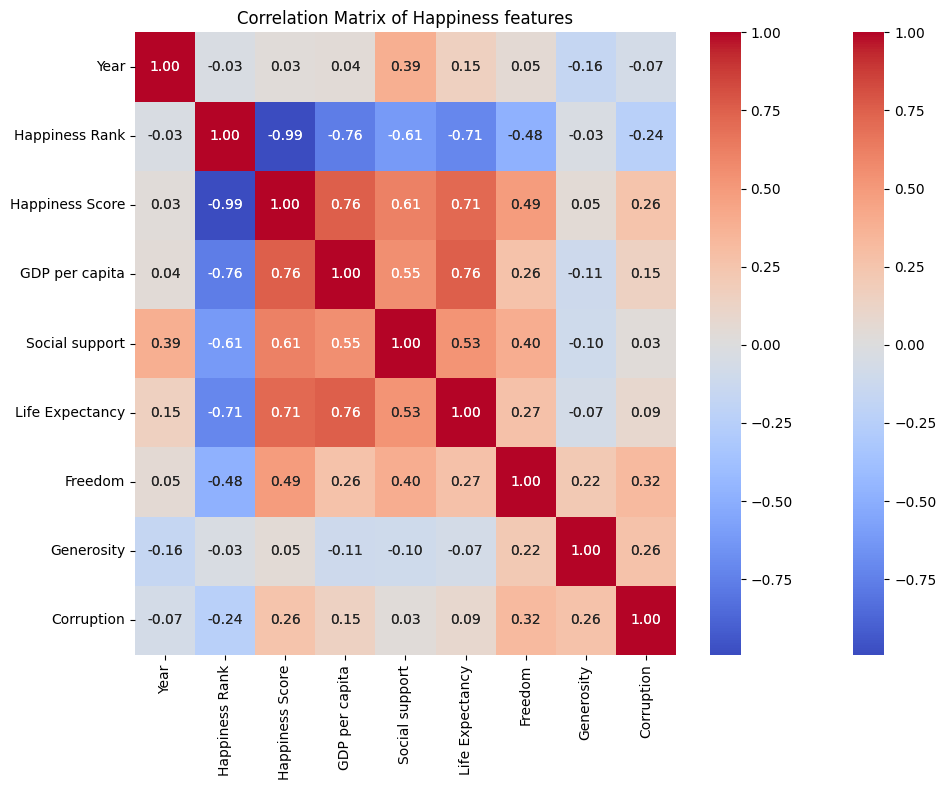

In [7]:
#EDA

#Correlation matrix
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print("=== Correlation Matrix ===")
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

#heatmap

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Correlation Matrix of Happiness features")
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()

In [8]:
clean_data_path = '/content/drive/MyDrive/ETL/workshop003/DATA/clean_data.csv'
df_clean.to_csv(clean_data_path, index = False)
print(f'\nCleaned dataset saved to {clean_data_path}')


Cleaned dataset saved to /content/drive/MyDrive/ETL/workshop003/DATA/clean_data.csv


In [ ]:
############## TRAINING MACHINE LEARNING MODEL ##############

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [10]:
def main():
  print("Loading dataset...")
  try:
    df = pd.read_csv('/content/drive/MyDrive/ETL/workshop003/DATA/clean_data.csv')
  except FileNotFoundError:
    print('File not found. Please run the EDA Save path ceiling.')
    return

  features = ['GDP per capita', 'Social support', 'Life Expectancy', 'Freedom', 'Generosity', 'Corruption']
  target = ['Happiness Score']

  x = df[features]
  y = df[target]

  print('using method Train/test (70/30)')
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

#including country, year and act score for more database context

  streaming_df = x_test.copy()
  streaming_df['Actual_Happiness_Score'] = y_test
  streaming_df['Country'] = df.loc[x_test.index, 'Country']
  streaming_df['Year'] = df.loc[x_test.index, 'Year']

  path = '/content/drive/MyDrive/ETL/workshop003/DATA/streaming_data.csv'
  streaming_df.to_csv(path, index=False)
  print(f'Streaming data saved to {path}')

  #model_training
  print("\nTraining Random Forest Regressor...")
  model = RandomForestRegressor(n_estimators=100, random_state=42)
  model.fit(x_train, y_train)

  #evaluating model
  print("\nEvaluating model...")
  y_pred = model.predict(x_test)

  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print(f'Mean Absolute Error: {mae}: {mae:.4f}')
  print(f'Mean Squared Error: {mse} : {mse:.4f}')
  print(f'R2 Score: {r2} : {r2:.4f}')

  # Saving models

  print("\nSaving models...")
  model_filename = '/content/drive/MyDrive/ETL/workshop003/DATA/happiness_model.pkl'
  joblib.dump(model, model_filename)
  print(f"\nModel successfully saved as '{model_filename}'")



In [11]:
if __name__ == "__main__":
    main()

Loading dataset...
using method Train/test (70/30)
Streaming data saved to /content/drive/MyDrive/ETL/workshop003/DATA/streaming_data.csv

Training Random Forest Regressor...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Evaluating model...
Mean Absolute Error: 0.3988698580148906: 0.3989
Mean Squared Error: 0.24512360091305554 : 0.2451
R2 Score: 0.7566714947110347 : 0.7567

Saving models...

Model successfully saved as '/content/drive/MyDrive/ETL/workshop003/DATA/happiness_model.pkl'


In [ ]:
############## KAFKA ##############

In [12]:
!pip install kafka-python

In [24]:
import json
import time
from kafka import KafkaProducer

In [25]:
def json_serializer(data):
    """Serializes dictionaries into JSON format for Kafka."""
    return json.dumps(data).encode('utf-8')

In [26]:
def main():
    print("Starting Kafka Producer...")

    # 1. Initialize the Kafka Producer
    # Assuming Kafka is running on the default local port (localhost:9092)
    try:
        producer = KafkaProducer(
            bootstrap_servers=['localhost:9092'],
            value_serializer=json_serializer
        )
        print("Successfully connected to Kafka!")
    except Exception as e:
        print(f"Error connecting to Kafka: {e}")
        print("Please make sure your Zookeeper and Kafka servers are running.")
        return

    # 2. Load the streaming data
    file_path = '/content/drive/MyDrive/ETL/workshop003/DATA/streaming_data.csv'
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}")
        return

    topic_name = 'happiness_predictions'

    # 3. Stream the data record by record
    print(f"Streaming {len(df)} records to topic '{topic_name}'...")

    for index, row in df.iterrows():
        # Convert the pandas row into a Python dictionary
        record = row.to_dict()

        # Send the record to the Kafka topic
        producer.send(topic_name, value=record)

        # Print to console so we can see it working
        print(f"Sent: Country={record.get('Country', 'Unknown')}, Year={record.get('Year', 'Unknown')}")

        # Sleep for 1 second to simulate real-time data streaming
        time.sleep(1)

    # Ensure all messages are sent before closing
    producer.flush()
    print("Streaming completed successfully!")

In [16]:
# 1. Java
!apt-get install openjdk-11-jre-headless -qq > /dev/null

# 2. Apache Kafka
!curl -sO https://archive.apache.org/dist/kafka/3.6.1/kafka_2.12-3.6.1.tgz
!tar -xzf kafka_2.12-3.6.1.tgz

# 3. Start Zookeeper
print("Starting Zookeeper...")
!nohup kafka_2.12-3.6.1/bin/zookeeper-server-start.sh kafka_2.12-3.6.1/config/zookeeper.properties > zookeeper.log 2>&1 &
time.sleep(5) # Give Zookeeper a few seconds to boot up

# 4. Start the Kafka Server
print("Starting Kafka Server...")
!nohup kafka_2.12-3.6.1/bin/kafka-server-start.sh kafka_2.12-3.6.1/config/server.properties > kafka.log 2>&1 &
time.sleep(15) # Give Kafka time to boot up completely

print("Kafka and Zookeeper are now running in the background")

Starting Zookeeper...
Starting Kafka Server...
Kafka and Zookeeper are now running in the background


In [27]:
if __name__ == "__main__":
    main()

Starting Kafka Producer...
Successfully connected to Kafka!
Streaming 206 records to topic 'happiness_predictions'...
Sent: Country=Senegal, Year=2018
Sent: Country=Ukraine, Year=2016
Sent: Country=Nigeria, Year=2016
Sent: Country=Cambodia, Year=2015
Sent: Country=Liberia, Year=2019
Sent: Country=Tanzania, Year=2018
Sent: Country=Netherlands, Year=2017
Sent: Country=Mongolia, Year=2016
Sent: Country=Uruguay, Year=2016
Sent: Country=Kuwait, Year=2019
Sent: Country=Somalia, Year=2017
Sent: Country=Serbia, Year=2019
Sent: Country=Israel, Year=2018
Sent: Country=Turkmenistan, Year=2019
Sent: Country=Iran, Year=2019
Sent: Country=Angola, Year=2018
Sent: Country=Zimbabwe, Year=2015
Sent: Country=Nigeria, Year=2015
Sent: Country=Algeria, Year=2019
Sent: Country=Cyprus, Year=2016
Sent: Country=Moldova, Year=2017
Sent: Country=Kenya, Year=2019
Sent: Country=Guatemala, Year=2017
Sent: Country=Poland, Year=2017
Sent: Country=Latvia, Year=2019
Sent: Country=Comoros, Year=2016
Sent: Country=Zimbabw

In [18]:
import json
import joblib
import sqlite3
from kafka import KafkaConsumer

In [19]:
def json_deserializer(data):
    """Convierte los bytes de Kafka de vuelta a un diccionario de Python."""
    return json.loads(data.decode('utf-8'))

In [20]:
def main():
    print("Iniciando el Consumidor de Kafka...")

    # Machine learning model
    model_path = '/content/drive/MyDrive/ETL/workshop003/DATA/happiness_model.pkl'
    try:
        model = joblib.load(model_path)
        print("Model uploaded")
    except FileNotFoundError:
        print(f"Model doesn't exists in {model_path}")
        return

    # SQLite database
    db_path = '/content/drive/MyDrive/ETL/workshop003/DATA/happiness_predictions.db'
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    # Make table if doesn't exists
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS predictions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            country TEXT,
            year INTEGER,
            gdp_per_capita REAL,
            social_support REAL,
            life_expectancy REAL,
            freedom REAL,
            generosity REAL,
            corruption REAL,
            actual_score REAL,
            predicted_score REAL
        )
    ''')
    conn.commit()
    print(f"database connected on {db_path}")

    # innit kafka consumer
    try:
        consumer = KafkaConsumer(
            'happiness_predictions',
            bootstrap_servers=['localhost:9092'],
            value_deserializer=json_deserializer,
            auto_offset_reset='earliest',
            enable_auto_commit=True,
            consumer_timeout_ms=10000
        )
        print("Connected to kafka. Listennig...\n")
    except Exception as e:
        print(f"ERROR Kafka not connected {e}")
        return

    #Model features
    features = ['GDP per capita', 'Social support', 'Life Expectancy', 'Freedom', 'Generosity', 'Corruption']

    # Process rt-messages
    proccesed_messages = 0
    try:
        for message in consumer:
            record = message.value

            # Extract characteristics
            x_input = pd.DataFrame([record])[features]

            # Predict score
            predicted_score = model.predict(x_input)[0]

            # Insert on Database
            cursor.execute('''
                INSERT INTO predictions (
                    country, year, gdp_per_capita, social_support, life_expectancy,
                    freedom, generosity, corruption, actual_score, predicted_score
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            ''', (
                record.get('Country', 'Unknown'),
                record.get('Year', 0),
                record.get('GDP per capita', 0),
                record.get('Social support', 0),
                record.get('Life Expectancy', 0),
                record.get('Freedom', 0),
                record.get('Generosity', 0),
                record.get('Corruption', 0),
                record.get('Actual_Happiness_Score', 0),
                predicted_score
            ))
            conn.commit()

            proccesed_messages += 1
            print(f"Guardado: {record.get('Country')} ({record.get('Year')}) | Real: {record.get('Actual_Happiness_Score'):.2f} -> Predicción: {predicted_score:.2f}")

    except KeyboardInterrupt:
        print("\nManually stoping consumer")
    finally:
        # Close all connections safely
        consumer.close()
        conn.close()
        print(f"\nProccess finished. Predicts saved in DB: {proccesed_messages}")


In [21]:
if __name__ == "__main__":
    main()

Iniciando el Consumidor de Kafka...
Model uploaded
database connected on /content/drive/MyDrive/ETL/workshop003/DATA/happiness_predictions.db
Connected to kafka. Listennig...

Guardado: Senegal (2018) | Real: 4.63 -> Predicción: 4.08
Guardado: Ukraine (2016) | Real: 4.32 -> Predicción: 4.86
Guardado: Nigeria (2016) | Real: 4.88 -> Predicción: 4.63
Guardado: Cambodia (2015) | Real: 3.82 -> Predicción: 4.78
Guardado: Liberia (2019) | Real: 3.98 -> Predicción: 4.31
Guardado: Tanzania (2018) | Real: 3.30 -> Predicción: 4.07
Guardado: Netherlands (2017) | Real: 7.38 -> Predicción: 7.09
Guardado: Mongolia (2016) | Real: 4.91 -> Predicción: 5.08
Guardado: Uruguay (2016) | Real: 6.54 -> Predicción: 6.40
Guardado: Kuwait (2019) | Real: 6.02 -> Predicción: 6.24
Guardado: Somalia (2017) | Real: 5.15 -> Predicción: 4.41
Guardado: Serbia (2019) | Real: 5.60 -> Predicción: 5.11
Guardado: Israel (2018) | Real: 6.81 -> Predicción: 6.85
Guardado: Turkmenistan (2019) | Real: 5.25 -> Predicción: 5.61
Gua